# Name: Vedant Kolhapure
# Roll No.: 33
# Div: B
# Dept: TE (AI&DS)
# Sub: SL-III LAB

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import joblib
import warnings
warnings.filterwarnings('ignore')

In [9]:
df = pd.read_csv('student_performance_dirty.csv')
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index,Notes
0,7.0,99,Yes,9.0,1,91.0,excellent
1,4.0,82,No,4.0,2,65.0,review
2,8.0,51,Yes,7.0,2,45.0,review
3,5.0,52,Yes,5.0,2,36.0,excellent
4,7.0,75,No,8.0,5,66.0,review


In [10]:
print("=== Descriptive Statistics ===")
print(df.describe(include='all'))
print("\nInfo:")
print(df.info())
print("\nMissing Values (%):")
print(df.isnull().sum() / len(df) * 100)
print("\nDuplicate Rows:", df.duplicated().sum())

=== Descriptive Statistics ===
        Hours Studied  Previous Scores Extracurricular Activities  \
count     8973.000000     10005.000000                      10005   
unique            NaN              NaN                          2   
top               NaN              NaN                         No   
freq              NaN              NaN                       5054   
mean         4.997325        69.437581                        NaN   
std          2.590449        17.343872                        NaN   
min          1.000000        40.000000                        NaN   
25%          3.000000        54.000000                        NaN   
50%          5.000000        69.000000                        NaN   
75%          7.000000        85.000000                        NaN   
max          9.000000        99.000000                        NaN   

        Sleep Hours  Sample Question Papers Practiced  Performance Index  \
count   9509.000000                      10005.000000       1000

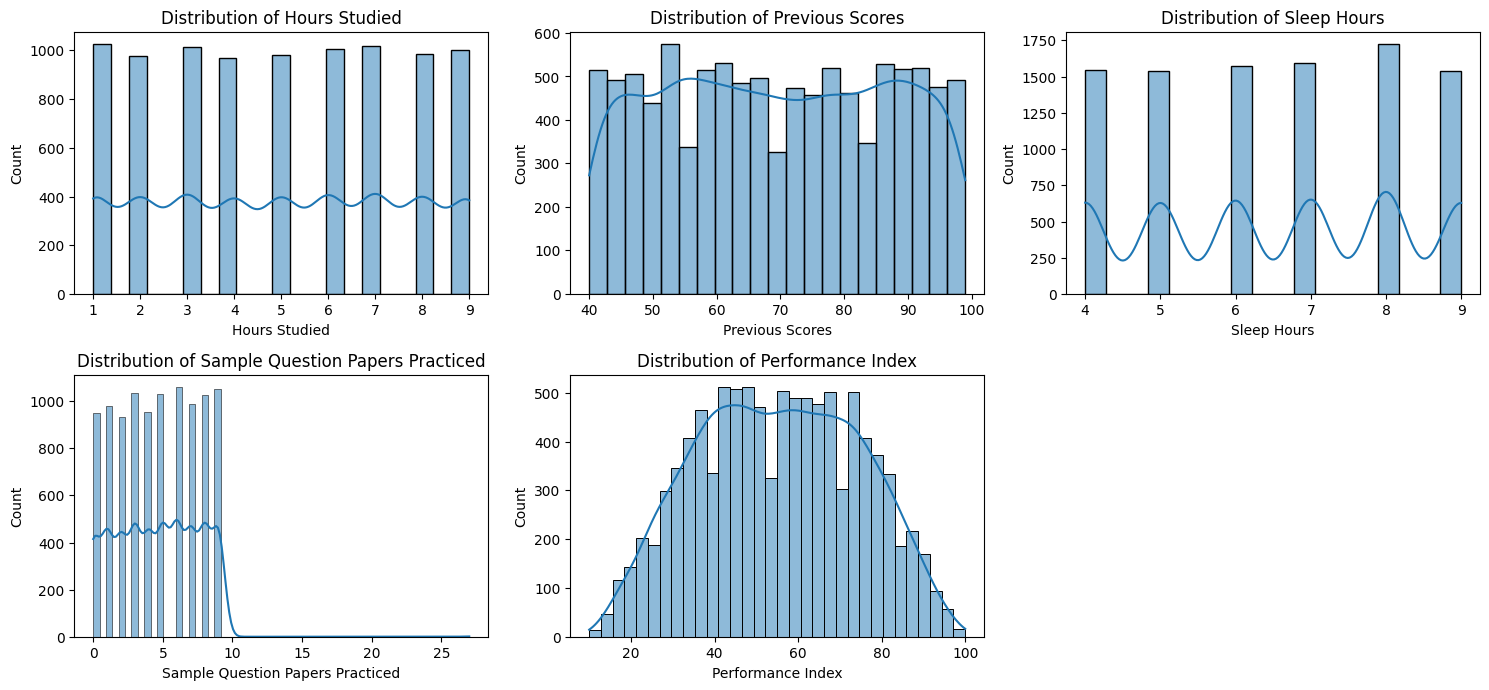

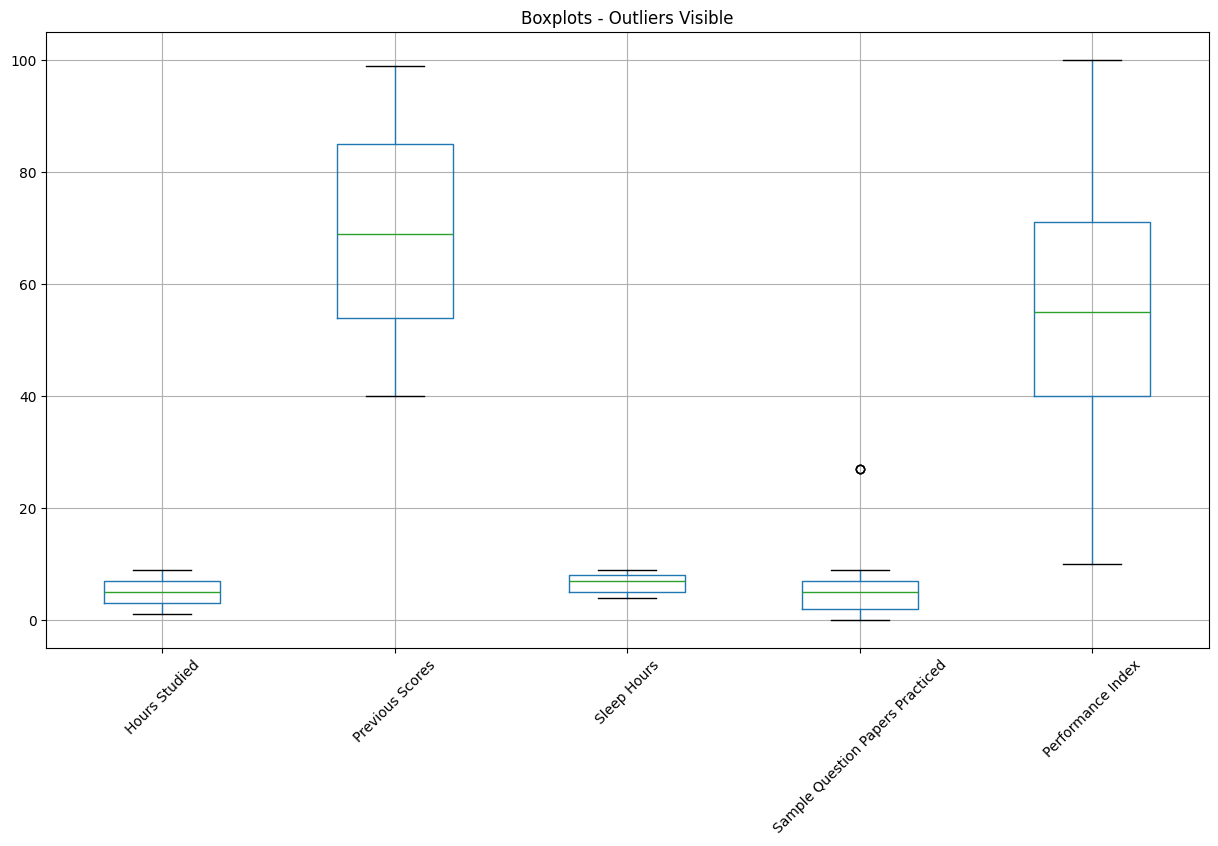

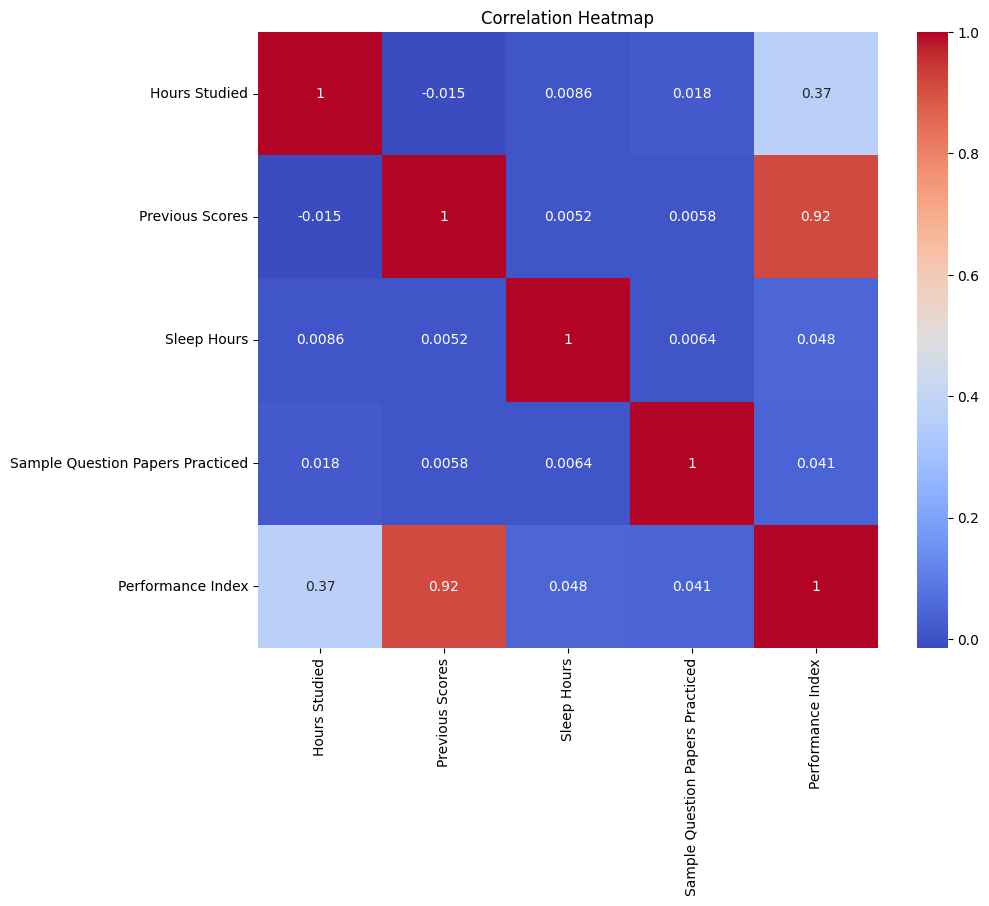

In [11]:
# 1. Histograms + Boxplots for outliers
plt.figure(figsize=(15, 10))
for i, col in enumerate(df.select_dtypes(include=np.number).columns, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

# Boxplots to spot outliers
plt.figure(figsize=(15, 8))
df.select_dtypes(include=np.number).boxplot(rot=45)
plt.title("Boxplots - Outliers Visible")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=np.number)
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [12]:
# 3.1 Fix data types & clean dirty values
# (The dataset often has string issues, extra commas, or inconsistent Yes/No)
df.columns = df.columns.str.strip()  # Clean column names

# Convert categorical to proper format
df['Extracurricular Activities'] = df['Extracurricular Activities'].astype(str).str.strip().str.lower()
df['Notes'] = df['Notes'].astype(str).str.strip().str.lower()

# Encode binary column
df['Extracurricular Activities'] = df['Extracurricular Activities'].map({'yes': 1, 'true': 1, 'no': 0, 'false': 0})

# Handle 'Notes' (optional feature engineering - you can drop or encode)
# For simplicity, we'll drop 'Notes' if it's too noisy (or encode it)
df = df.drop(columns=['Notes'], errors='ignore')   # Many notebooks drop it

# 3.2 Handle missing values (if any)
df = df.fillna(df.median(numeric_only=True))

# 3.3 Handling Outliers (IQR Method - very important for this dirty dataset)
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[column] >= lower) & (df[column] <= upper)]

numeric_cols = ['Hours Studied', 'Previous Scores', 'Sleep Hours', 
                'Sample Question Papers Practiced', 'Performance Index']

for col in numeric_cols:
    df = remove_outliers_iqr(df, col)

print("Shape after outlier removal:", df.shape)

# 3.4 Data Normalization / Scaling
scaler = StandardScaler()
features = ['Hours Studied', 'Previous Scores', 'Sleep Hours', 
            'Sample Question Papers Practiced', 'Extracurricular Activities']

X = df[features]
y = df['Performance Index']

X_scaled = scaler.fit_transform(X)
X = pd.DataFrame(X_scaled, columns=features)

print("✅ Preprocessing Completed!")

Shape after outlier removal: (10002, 6)
✅ Preprocessing Completed!


In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 1. Linear Regression (Baseline)
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# 2. Random Forest Regressor + Hyperparameter Tuning
rf = RandomForestRegressor(random_state=42)
param_rf = {'n_estimators': [50, 100], 'max_depth': [10, 15]}
grid_rf = GridSearchCV(rf, param_rf, cv=3, scoring='r2')
grid_rf.fit(X_train, y_train)
best_rf = grid_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test)

# 3. XGBoost Regressor + Hyperparameter Tuning
xgb = XGBRegressor(random_state=42)
param_xgb = {'n_estimators': [50, 100], 'max_depth': [6, 10], 'learning_rate': [0.1, 0.2]}
grid_xgb = GridSearchCV(xgb, param_xgb, cv=3, scoring='r2')
grid_xgb.fit(X_train, y_train)
best_xgb = grid_xgb.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)

# Model Comparison
models = {
    'Linear Regression': (y_pred_lr, lr),
    'Random Forest (Tuned)': (y_pred_rf, best_rf),
    'XGBoost (Tuned)': (y_pred_xgb, best_xgb)
}

results = []
for name, (pred, model) in models.items():
    results.append({
        'Model': name,
        'R² Score': r2_score(y_test, pred),
        'MAE': mean_absolute_error(y_test, pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, pred))
    })

comparison_df = pd.DataFrame(results)
print(comparison_df.round(4))

# Save all three models
joblib.dump(lr, 'linear_regression_model.pkl')
joblib.dump(best_rf, 'random_forest_model.pkl')
joblib.dump(best_xgb, 'xgboost_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

# Save the best model (XGBoost) for backward compatibility
joblib.dump(best_xgb, 'best_model.pkl')

# Export comparison results as JSON for frontend
import json
results_json = comparison_df.to_dict(orient='records')
for r in results_json:
    r['R² Score'] = round(float(r['R² Score']), 4)
    r['MAE'] = round(float(r['MAE']), 4)
    r['RMSE'] = round(float(r['RMSE']), 4)

with open('model_results.json', 'w') as f:
    json.dump(results_json, f, indent=2)

print("✅ All models saved!")
print("   - linear_regression_model.pkl")
print("   - random_forest_model.pkl")
print("   - xgboost_model.pkl")
print("   - scaler.pkl")
print("   - model_results.json")

                   Model  R² Score     MAE    RMSE
0      Linear Regression    0.9747  2.1218  3.0642
1  Random Forest (Tuned)    0.9698  2.3810  3.3442
2        XGBoost (Tuned)    0.9724  2.2442  3.1990
✅ All models saved!
   - linear_regression_model.pkl
   - random_forest_model.pkl
   - xgboost_model.pkl
   - scaler.pkl
   - model_results.json
